In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# Tickers
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS",
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS",
    "HINDUNILVR.NS", "ITC.NS"
]

# Download
prices = yf.download(TICKERS, start="2015-01-01", end="2024-12-31", auto_adjust=True)["Close"].dropna()

print(prices.shape)
print(prices.head())

[*********************100%***********************]  8 of 8 completed

(2466, 8)
Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS     INFY.NS      ITC.NS  \
Date                                                                           
2015-01-01   217.235352     633.171814    294.023834  367.770874  161.223801   
2015-01-02   220.258698     631.084839    302.369720  374.998047  161.728806   
2015-01-05   218.399063     634.716309    302.995605  371.775574  162.365570   
2015-01-06   214.999237     646.737732    290.143066  364.008118  158.193863   
2015-01-07   215.626694     669.445190    282.297974  365.749786  155.251770   

Ticker      RELIANCE.NS     SBIN.NS       TCS.NS  
Date                                              
2015-01-01   189.999802  274.924988   988.879761  
2015-01-02   189.496948  276.019440  1002.049072  
2015-01-05   187.421295  273.830536   986.820740  
2015-01-06   178.915237  262.579681   950.439880  
2015-01-07   182.809830  262.798523   939.213623  


In [2]:
returns = np.log(prices / prices.shift(1)).dropna()

print(returns.shape)
print(returns.head())

(2465, 8)
Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Date                                                                       
2015-01-02     0.013821      -0.003302      0.027990  0.019461  0.003127   
2015-01-05    -0.008479       0.005738      0.002068 -0.008630  0.003930   
2015-01-06    -0.015689       0.018763     -0.043344 -0.021114 -0.026029   
2015-01-07     0.002914       0.034508     -0.027411  0.004773 -0.018773   
2015-01-08     0.020788       0.018716      0.026836  0.005029  0.024724   

Ticker      RELIANCE.NS   SBIN.NS    TCS.NS  
Date                                         
2015-01-02    -0.002650  0.003973  0.013230  
2015-01-05    -0.011014 -0.007962 -0.015314  
2015-01-06    -0.046447 -0.041955 -0.037563  
2015-01-07     0.021534  0.000833 -0.011882  
2015-01-08    -0.014443  0.015538  0.010737  


In [3]:
mean_ret = returns.mean(axis=1)

# Rolling volatility — how chaotic is the market
roll_vol = mean_ret.rolling(20).std().fillna(method='bfill')

# Drawdown feature — how far are we from recent peak
cum_ret = mean_ret.cumsum()
rolling_max = cum_ret.rolling(60).max().fillna(method='bfill')
drawdown = (cum_ret - rolling_max)

# 5 day momentum
momentum = mean_ret.rolling(5).mean().fillna(method='bfill')

X = np.hstack([
    mean_ret.values.reshape(-1, 1),
    roll_vol.values.reshape(-1, 1),
    drawdown.values.reshape(-1, 1),
    momentum.values.reshape(-1, 1)
])

print(X.shape)
print(X[:5])

(2465, 4)
[[ 0.00945626  0.01223204 -0.06703718 -0.00157429]
 [-0.00495797  0.01223204 -0.07199515 -0.00157429]
 [-0.02667243  0.01223204 -0.09866758 -0.00157429]
 [ 0.00081215  0.01223204 -0.09785543 -0.00157429]
 [ 0.01349053  0.01223204 -0.0843649  -0.00157429]]


In [4]:
model = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=2000,
    random_state=42
)
model.transmat_ = np.array([
    [0.97, 0.01, 0.01, 0.01],
    [0.01, 0.97, 0.01, 0.01],
    [0.01, 0.01, 0.97, 0.01],
    [0.01, 0.01, 0.01, 0.97]
])
model.fit(X)
print("Converged:", model.monitor_.converged)
print("Log-likelihood:", model.score(X))

Converged: True
Log-likelihood: 37215.86298643138


In [5]:
hidden_states = model.predict(X)

print(hidden_states[:20])
print("Unique states:", np.unique(hidden_states))

[0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 1 1 3]
Unique states: [0 1 2 3]


In [6]:
# Find mean return for each state
state_means = []
for s in range(4):
    mask = hidden_states == s
    avg = returns[mask].mean(axis=1).mean()
    days = mask.sum()
    state_means.append(avg)
    print(f"State {s}: mean return = {avg:.6f}, days = {days}")

# Sort all 4 states by mean return descending
order = np.argsort(state_means)[::-1]

# Top 2 returns → Bull and Sideways, Bottom 2 → Bear
def map_to_regime(state):
    rank = list(order).index(state)
    if rank == 0:
        return 0   # Bull
    elif rank == 1:
        return 1   # Sideways
    else:
        return 2   # Bear (merges rank 2 and 3)

regimes = np.array([map_to_regime(s) for s in hidden_states])

REGIME_NAMES  = {0: "Bull", 1: "Sideways", 2: "Bear"}
REGIME_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#F44336"}

print("\nAfter merging:")
for r in range(3):
    days = (regimes == r).sum()
    print(f"  {REGIME_NAMES[r]}: {days} days ({days/len(regimes)*100:.1f}%)")

regime_map = {old: list(order).index(old) for old in range(4)}
print(regime_map)

State 0: mean return = -0.000016, days = 531
State 1: mean return = 0.001730, days = 1041
State 2: mean return = -0.001120, days = 80
State 3: mean return = -0.000400, days = 813

After merging:
  Bull: 1041 days (42.2%)
  Sideways: 531 days (21.5%)
  Bear: 893 days (36.2%)
{0: 1, 1: 0, 2: 3, 3: 2}


In [7]:
print("── Regime Summary ──────────────────────────────────────")
for r in range(3):
    mask = regimes == r
    ann_ret = returns[mask].mean(axis=1).mean() * 252
    ann_vol = returns[mask].mean(axis=1).std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    print(f"  {REGIME_NAMES[r]:10s} | {mask.sum():4d} days "
          f"| ann. return: {ann_ret:+.1%} "
          f"| ann. vol: {ann_vol:.1%} "
          f"| Sharpe: {sharpe:.2f}")

── Regime Summary ──────────────────────────────────────
  Bull       | 1041 days | ann. return: +43.6% | ann. vol: 10.6% | Sharpe: 4.11
  Sideways   |  531 days | ann. return: -0.4% | ann. vol: 16.2% | Sharpe: -0.02
  Bear       |  893 days | ann. return: -11.7% | ann. vol: 22.0% | Sharpe: -0.53


In [8]:
from scipy.ndimage import uniform_filter1d

# Smooth regimes — apply a rolling window majority vote
# Each day takes the most common regime in a 15 day window around it
def smooth_regimes(regimes, window=15):
    smoothed = regimes.copy()
    half = window // 2
    for i in range(len(regimes)):
        start = max(0, i - half)
        end   = min(len(regimes), i + half)
        window_vals = regimes[start:end]
        smoothed[i] = np.bincount(window_vals).argmax()
    return smoothed

regimes = smooth_regimes(regimes, window=60)

# Check new distribution
print("After smoothing:")
for r in range(3):
    days = (regimes == r).sum()
    print(f"  {REGIME_NAMES[r]}: {days} days ({days/len(regimes)*100:.1f}%)")

After smoothing:
  Bull: 1197 days (48.6%)
  Sideways: 613 days (24.9%)
  Bear: 655 days (26.6%)


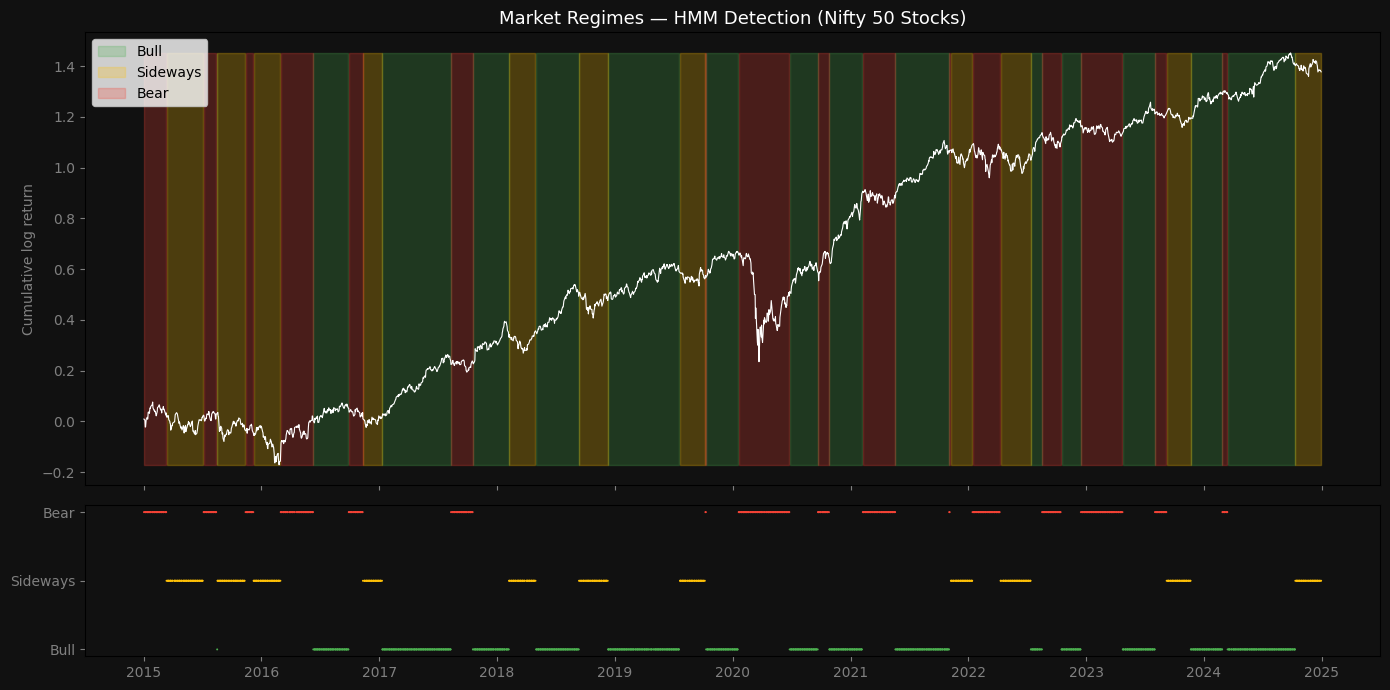

Saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), 
                                sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# Cumulative return
cum = returns.mean(axis=1).cumsum()

# Top plot — cumulative return shaded by regime
ax1.plot(returns.index, cum, color="white", linewidth=0.8, zorder=3)
for r in range(3):
    mask = regimes == r
    ax1.fill_between(returns.index, cum.min(), cum.max(),
                     where=mask,
                     color=REGIME_COLORS[r],
                     alpha=0.25,
                     label=REGIME_NAMES[r])

ax1.set_title("Market Regimes — HMM Detection (Nifty 50 Stocks)", fontsize=13)
ax1.set_ylabel("Cumulative log return")
ax1.legend(loc="upper left")
ax1.set_facecolor("#111111")
fig.patch.set_facecolor("#111111")
ax1.tick_params(colors="gray")
ax1.yaxis.label.set_color("gray")
ax1.title.set_color("white")

# Bottom plot — regime strip
ax2.scatter(returns.index, regimes,
            c=[REGIME_COLORS[r] for r in regimes],
            s=2, linewidths=0)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["Bull", "Sideways", "Bear"])
ax2.set_facecolor("#111111")
ax2.tick_params(colors="gray")
ax2.yaxis.label.set_color("gray")

plt.tight_layout()
plt.savefig("regime_plot.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved!")

In [10]:
# Split returns into three buckets by regime
bull_returns     = returns[regimes == 0]
sideways_returns = returns[regimes == 1]
bear_returns     = returns[regimes == 2]

print(f"Bull days:     {len(bull_returns)}")
print(f"Sideways days: {len(sideways_returns)}")
print(f"Bear days:     {len(bear_returns)}")

# Compute mean return vector and covariance matrix for each regime
bull_mean     = bull_returns.mean().values
bull_cov      = bull_returns.cov().values

sideways_mean = sideways_returns.mean().values
sideways_cov  = sideways_returns.cov().values

bear_mean     = bear_returns.mean().values
bear_cov      = bear_returns.cov().values

print("\nBull mean returns:")
print(dict(zip(returns.columns, bull_mean.round(6))))

print("\nBear mean returns:")
print(dict(zip(returns.columns, bear_mean.round(6))))

Bull days:     1197
Sideways days: 613
Bear days:     655

Bull mean returns:
{'HDFCBANK.NS': np.float64(0.001216), 'HINDUNILVR.NS': np.float64(0.000682), 'ICICIBANK.NS': np.float64(0.001862), 'INFY.NS': np.float64(0.001524), 'ITC.NS': np.float64(0.000803), 'RELIANCE.NS': np.float64(0.001702), 'SBIN.NS': np.float64(0.002421), 'TCS.NS': np.float64(0.00124)}

Bear mean returns:
{'HDFCBANK.NS': np.float64(0.000256), 'HINDUNILVR.NS': np.float64(0.000292), 'ICICIBANK.NS': np.float64(-0.000126), 'INFY.NS': np.float64(-6.3e-05), 'ITC.NS': np.float64(0.000304), 'RELIANCE.NS': np.float64(-0.000278), 'SBIN.NS': np.float64(-0.000714), 'TCS.NS': np.float64(-9.6e-05)}


In [11]:
from scipy.optimize import minimize

def max_sharpe(mean_ret, cov, rf=0.0001):
    n = len(mean_ret)
    
    def neg_sharpe(weights):
        port_ret = np.dot(weights, mean_ret)
        port_vol = np.sqrt(weights @ cov @ weights)
        return -(port_ret - rf) / port_vol
    
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0, 0.40)] * n
    w0 = np.ones(n) / n
    
    result = minimize(neg_sharpe, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints)
    return result.x

# Optimize for each regime
bull_weights     = max_sharpe(bull_mean, bull_cov)
sideways_weights = max_sharpe(sideways_mean, sideways_cov)
bear_weights     = max_sharpe(bear_mean, bear_cov)

tickers = returns.columns.tolist()

print("Bull portfolio:")
for t, w in zip(tickers, bull_weights):
    print(f"  {t:20s} {w:.1%}")

print("\nSideway portfolio:")
for t, w in zip(tickers, sideways_weights):
    print(f"  {t:20s} {w:.1%}")

print("\nBear portfolio:")
for t, w in zip(tickers, bear_weights):
    print(f"  {t:20s} {w:.1%}")

Bull portfolio:
  HDFCBANK.NS          16.5%
  HINDUNILVR.NS        7.3%
  ICICIBANK.NS         10.6%
  INFY.NS              15.7%
  ITC.NS               0.0%
  RELIANCE.NS          19.6%
  SBIN.NS              15.5%
  TCS.NS               14.8%

Sideway portfolio:
  HDFCBANK.NS          0.0%
  HINDUNILVR.NS        40.0%
  ICICIBANK.NS         0.0%
  INFY.NS              0.0%
  ITC.NS               0.0%
  RELIANCE.NS          34.5%
  SBIN.NS              0.0%
  TCS.NS               25.5%

Bear portfolio:
  HDFCBANK.NS          21.0%
  HINDUNILVR.NS        40.0%
  ICICIBANK.NS         0.0%
  INFY.NS              0.0%
  ITC.NS               39.0%
  RELIANCE.NS          0.0%
  SBIN.NS              0.0%
  TCS.NS               0.0%


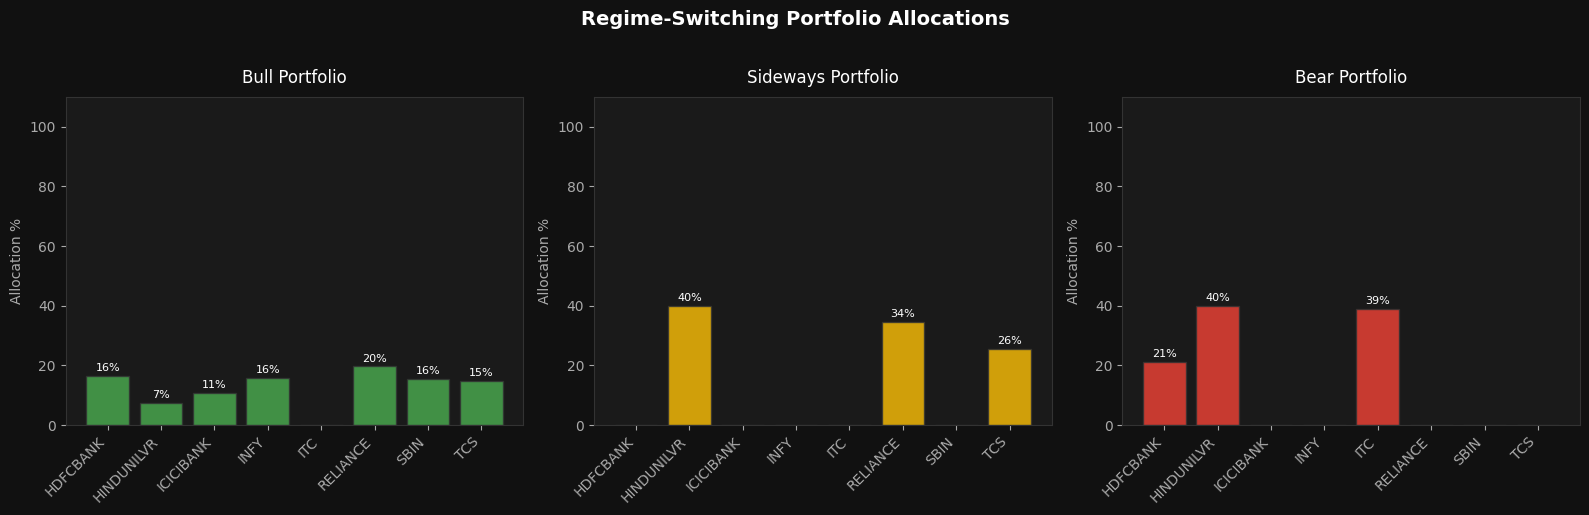

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#111111")

portfolios = {
    "Bull":     (bull_weights,     "#4CAF50"),
    "Sideways": (sideways_weights, "#FFC107"),
    "Bear":     (bear_weights,     "#F44336")
}

short_tickers = [t.replace(".NS", "") for t in tickers]

for ax, (name, (weights, color)) in zip(axes, portfolios.items()):
    ax.set_facecolor("#1a1a1a")
    bars = ax.bar(short_tickers, weights * 100, color=color, alpha=0.8, edgecolor="#333")
    ax.set_title(f"{name} Portfolio", color="white", fontsize=12, pad=10)
    ax.set_ylabel("Allocation %", color="#aaa")
    ax.tick_params(colors="#aaa", axis="both")
    ax.set_ylim(0, 110)
    for spine in ax.spines.values():
        spine.set_color("#333")
    for bar, w in zip(bars, weights):
        if w > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{w:.0%}", ha="center", va="bottom", color="white", fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.suptitle("Regime-Switching Portfolio Allocations", color="white", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("portfolio_weights.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

In [13]:
# Generate efficient frontier for each regime
def get_frontier(mean_ret, cov, n_points=100):
    n = len(mean_ret)
    results = []
    
    # Generate random portfolios
    for _ in range(5000):
        w = np.random.dirichlet(np.ones(n))
        ret = np.dot(w, mean_ret) * 252
        vol = np.sqrt(w @ cov @ w) * np.sqrt(252)
        sharpe = (ret - 0.0001*252) / vol
        results.append((vol, ret, sharpe))
    
    return zip(*results)

bull_vol,     bull_ret,     bull_sharpe     = get_frontier(bull_mean,     bull_cov)
sideways_vol, sideways_ret, sideways_sharpe = get_frontier(sideways_mean, sideways_cov)
bear_vol,     bear_ret,     bear_sharpe     = get_frontier(bear_mean,     bear_cov)

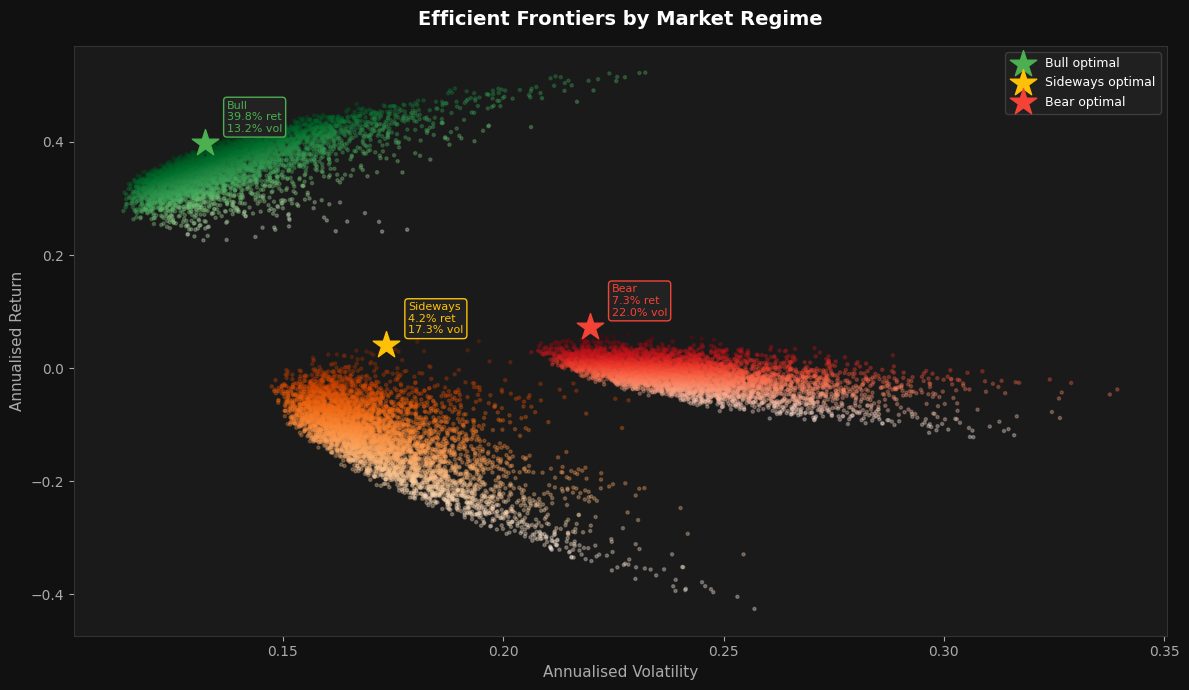

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#1a1a1a")

# Plot scatter of random portfolios for each regime
ax.scatter(list(bull_vol), list(bull_ret), c=list(bull_sharpe),
           cmap="Greens", alpha=0.3, s=5, label="_nolegend_")

ax.scatter(list(sideways_vol), list(sideways_ret), c=list(sideways_sharpe),
           cmap="Oranges", alpha=0.3, s=5, label="_nolegend_")

ax.scatter(list(bear_vol), list(bear_ret), c=list(bear_sharpe),
           cmap="Reds", alpha=0.3, s=5, label="_nolegend_")

# Plot optimal portfolios as stars
regimes_data = [
    ("Bull",     bull_weights,     bull_mean,     bull_cov,     "#4CAF50"),
    ("Sideways", sideways_weights, sideways_mean, sideways_cov, "#FFC107"),
    ("Bear",     bear_weights,     bear_mean,     bear_cov,     "#F44336"),
]

for name, w, mean_ret, cov, color in regimes_data:
    ret = np.dot(w, mean_ret) * 252
    vol = np.sqrt(w @ cov @ w) * np.sqrt(252)
    ax.scatter(vol, ret, marker="*", s=400, color=color, 
               zorder=5, label=f"{name} optimal")
    ax.annotate(f"{name}\n{ret:.1%} ret\n{vol:.1%} vol",
                xy=(vol, ret), xytext=(vol+0.005, ret+0.02),
                color=color, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#222", edgecolor=color))

ax.set_xlabel("Annualised Volatility", color="#aaa", fontsize=11)
ax.set_ylabel("Annualised Return", color="#aaa", fontsize=11)
ax.set_title("Efficient Frontiers by Market Regime", color="white", 
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(colors="#aaa")
ax.legend(facecolor="#222", edgecolor="#444", labelcolor="white", fontsize=9)
for spine in ax.spines.values():
    spine.set_color("#333")

plt.tight_layout()
plt.savefig("efficient_frontiers.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

In [15]:
# Predict current regime from last 20 trading days
raw_probs = model.predict_proba(X[-20:]).mean(axis=0)

# Remap probabilities to 3 regimes (states 2 and 3 both map to Bear)
curr_probs = np.zeros(3)
for old in range(4):
    new = map_to_regime(old)   # use same function as before
    curr_probs[new] += raw_probs[old]

current_regime = int(np.argmax(curr_probs))

print("── Current Market Mood (last 20 trading days) ──────────")
for r in range(3):
    bar = "█" * int(curr_probs[r] * 40)
    print(f"  {REGIME_NAMES[r]:10s} {bar:<40s} {curr_probs[r]:.1%}")

print(f"\n  → Recommended portfolio: {REGIME_NAMES[current_regime]}")
print(f"\n  Allocations:")
weights_map = {0: bull_weights, 1: sideways_weights, 2: bear_weights}
for t, w in zip(tickers, weights_map[current_regime]):
    if w > 0.01:
        print(f"    {t.replace('.NS',''):15s} {w:.1%}")

── Current Market Mood (last 20 trading days) ──────────
  Bull                                                0.0%
  Sideways   ██████████████                           36.4%
  Bear       █████████████████████████                63.6%

  → Recommended portfolio: Bear

  Allocations:
    HDFCBANK        21.0%
    HINDUNILVR      40.0%
    ITC             39.0%


In [17]:
TEST_TICKERS = [
    "BAJFINANCE.NS",
    "ASIANPAINT.NS", 
    "SUNPHARMA.NS",
    "WIPRO.NS"
]

test_prices = yf.download(TEST_TICKERS, start="2015-01-01", 
                           end="2024-12-31", auto_adjust=True, 
                           progress=False)["Close"].dropna()

print(test_prices.shape)
print(test_prices.head())

(2466, 4)
Ticker      ASIANPAINT.NS  BAJFINANCE.NS  SUNPHARMA.NS   WIPRO.NS
Date                                                             
2015-01-01     684.931580      33.758137    752.939514  91.154793
2015-01-02     708.611389      33.218430    756.648254  91.963379
2015-01-05     708.565735      33.131618    757.106201  92.128410
2015-01-06     691.651489      33.045765    740.439331  89.974960
2015-01-07     705.548645      33.718582    741.583984  89.290123


In [18]:
test_returns = np.log(test_prices / test_prices.shift(1)).dropna()

print(test_returns.shape)
print(test_returns.head())

(2465, 4)
Ticker      ASIANPAINT.NS  BAJFINANCE.NS  SUNPHARMA.NS  WIPRO.NS
Date                                                            
2015-01-02       0.033988      -0.016117      0.004914  0.008831
2015-01-05      -0.000064      -0.002617      0.000605  0.001793
2015-01-06      -0.024161      -0.002595     -0.022260 -0.023652
2015-01-07       0.019894       0.020156      0.001545 -0.007641
2015-01-08       0.061135      -0.001704      0.011053  0.007182


In [19]:
# Align regimes with test returns dates
regime_series = pd.Series(regimes, index=returns.index)
aligned_regimes = regime_series.reindex(test_returns.index).fillna(method='ffill').values.astype(int)

print(f"Test returns shape: {test_returns.shape}")
print(f"Aligned regimes shape: {aligned_regimes.shape}")
print(f"Unique regimes: {np.unique(aligned_regimes)}")

Test returns shape: (2465, 4)
Aligned regimes shape: (2465,)
Unique regimes: [0 1 2]


In [21]:
# Split test returns by regime
test_bull     = test_returns[aligned_regimes == 0]
test_sideways = test_returns[aligned_regimes == 1]
test_bear     = test_returns[aligned_regimes == 2]

print(f"Bull days:     {len(test_bull)}")
print(f"Sideways days: {len(test_sideways)}")
print(f"Bear days:     {len(test_bear)}")

# Compute mean and cov for each regime on test stocks
test_bull_mean     = test_bull.mean().values
test_bull_cov      = test_bull.cov().values

test_sideways_mean = test_sideways.mean().values
test_sideways_cov  = test_sideways.cov().values

test_bear_mean     = test_bear.mean().values
test_bear_cov      = test_bear.cov().values

# Optimize portfolios for test stocks
test_bull_w     = max_sharpe(test_bull_mean,     test_bull_cov)
test_sideways_w = max_sharpe(test_sideways_mean, test_sideways_cov)
test_bear_w     = max_sharpe(test_bear_mean,     test_bear_cov)

test_tickers_short = [t.replace(".NS", "") for t in TEST_TICKERS]

print("\nTest Bull portfolio:")
for t, w in zip(test_tickers_short, test_bull_w):
    print(f"  {t:15s} {w:.1%}")

print("\nTest Sideways portfolio:")
for t, w in zip(test_tickers_short, test_sideways_w):
    print(f"  {t:15s} {w:.1%}")

print("\nTest Bear portfolio:")
for t, w in zip(test_tickers_short, test_bear_w):
    print(f"  {t:15s} {w:.1%}")

Bull days:     1197
Sideways days: 613
Bear days:     655

Test Bull portfolio:
  BAJFINANCE      19.5%
  ASIANPAINT      36.2%
  SUNPHARMA       12.3%
  WIPRO           31.9%

Test Sideways portfolio:
  BAJFINANCE      40.0%
  ASIANPAINT      40.0%
  SUNPHARMA       0.0%
  WIPRO           20.0%

Test Bear portfolio:
  BAJFINANCE      40.0%
  ASIANPAINT      0.0%
  SUNPHARMA       40.0%
  WIPRO           20.0%


In [22]:
# Build daily strategy returns
strategy_returns = []
benchmark_returns = []

for i, day in enumerate(test_returns.index):
    r = aligned_regimes[i]
    
    if r == 0:
        w = test_bull_w
    elif r == 1:
        w = test_sideways_w
    else:
        w = test_bear_w
    
    # Strategy return: weighted sum of that day's returns
    daily_ret = np.dot(test_returns.iloc[i].values, w)
    strategy_returns.append(daily_ret)
    
    # Benchmark: equal weight
    bench_ret = test_returns.iloc[i].mean()
    benchmark_returns.append(bench_ret)

strategy_returns  = np.array(strategy_returns)
benchmark_returns = np.array(benchmark_returns)

# Cumulative returns
strategy_cum  = np.exp(np.cumsum(strategy_returns)) - 1
benchmark_cum = np.exp(np.cumsum(benchmark_returns)) - 1

print(f"Strategy total return:  {strategy_cum[-1]:.1%}")
print(f"Benchmark total return: {benchmark_cum[-1]:.1%}")

Strategy total return:  751.4%
Benchmark total return: 376.5%


──────────────────────────────────────────────────────
Metric                   Strategy    Benchmark
──────────────────────────────────────────────────────
Ann. Return                 21.9%        16.0%
Ann. Volatility             19.8%        18.9%
Sharpe Ratio                 1.10         0.84
Max Drawdown               -27.7%       -32.7%
Total Return               751.4%       376.5%
──────────────────────────────────────────────────────


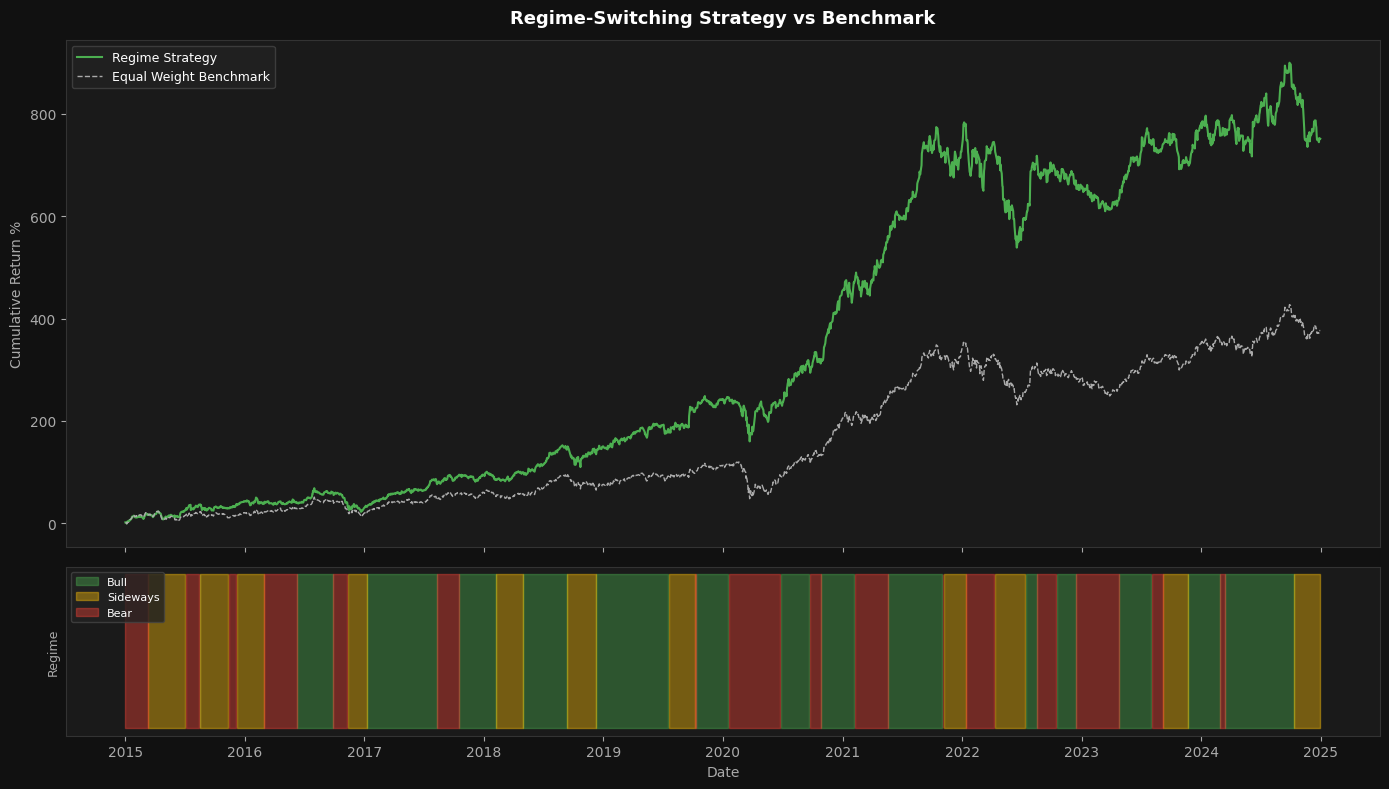

In [23]:
# Risk metrics
def compute_metrics(returns_arr):
    ann_ret    = np.mean(returns_arr) * 252
    ann_vol    = np.std(returns_arr) * np.sqrt(252)
    sharpe     = ann_ret / ann_vol
    cum        = np.exp(np.cumsum(returns_arr)) - 1
    rolling_max = np.maximum.accumulate(cum + 1)
    drawdown   = (cum + 1) / rolling_max - 1
    max_dd     = drawdown.min()
    return ann_ret, ann_vol, sharpe, max_dd

s_ret, s_vol, s_sharpe, s_dd = compute_metrics(strategy_returns)
b_ret, b_vol, b_sharpe, b_dd = compute_metrics(benchmark_returns)

print("──────────────────────────────────────────────────────")
print(f"{'Metric':20s} {'Strategy':>12s} {'Benchmark':>12s}")
print("──────────────────────────────────────────────────────")
print(f"{'Ann. Return':20s} {s_ret:>12.1%} {b_ret:>12.1%}")
print(f"{'Ann. Volatility':20s} {s_vol:>12.1%} {b_vol:>12.1%}")
print(f"{'Sharpe Ratio':20s} {s_sharpe:>12.2f} {b_sharpe:>12.2f}")
print(f"{'Max Drawdown':20s} {s_dd:>12.1%} {b_dd:>12.1%}")
print(f"{'Total Return':20s} {strategy_cum[-1]:>12.1%} {benchmark_cum[-1]:>12.1%}")
print("──────────────────────────────────────────────────────")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
fig.patch.set_facecolor("#111111")

dates = test_returns.index

# Top — cumulative returns
ax1.set_facecolor("#1a1a1a")
ax1.plot(dates, strategy_cum * 100,  color="#4CAF50", linewidth=1.5, label="Regime Strategy")
ax1.plot(dates, benchmark_cum * 100, color="#aaaaaa", linewidth=1.0, label="Equal Weight Benchmark", linestyle="--")
ax1.set_ylabel("Cumulative Return %", color="#aaa", fontsize=10)
ax1.set_title("Regime-Switching Strategy vs Benchmark", color="white", fontsize=13, fontweight="bold", pad=12)
ax1.legend(facecolor="#222", edgecolor="#444", labelcolor="white", fontsize=9)
ax1.tick_params(colors="#aaa")
for spine in ax1.spines.values():
    spine.set_color("#333")

# Bottom — regime background
ax2.set_facecolor("#1a1a1a")
for r, color in REGIME_COLORS.items():
    mask = aligned_regimes == r
    ax2.fill_between(dates, 0, 1, where=mask,
                     color=color, alpha=0.4, label=REGIME_NAMES[r])
ax2.set_yticks([])
ax2.set_xlabel("Date", color="#aaa", fontsize=10)
ax2.set_ylabel("Regime", color="#aaa", fontsize=9)
ax2.legend(facecolor="#222", edgecolor="#444", labelcolor="white", fontsize=8, loc="upper left")
ax2.tick_params(colors="#aaa")
for spine in ax2.spines.values():
    spine.set_color("#333")

plt.tight_layout()
plt.savefig("backtest.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

In [25]:
from google.colab import files
files.download('regime_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>